## 0. Import & Load Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

DATA_DIR = "../data/raw/"

print("Đang load data...")
log_main  = pd.read_csv(DATA_DIR + "log_standard_4_22_to_5_08_1k.csv")
log_prev  = pd.read_csv(DATA_DIR + "log_standard_4_08_to_4_21_1k.csv")
log_rand  = pd.read_csv(DATA_DIR + "log_random_4_22_to_5_08_1k.csv")
user_feat = pd.read_csv(DATA_DIR + "user_features_1k.csv")
vid_basic = pd.read_csv(DATA_DIR + "video_features_basic_1k.csv")

print(f" log_main  : {len(log_main):>10,} rows")
print(f" log_prev  : {len(log_prev):>10,} rows")
print(f" log_rand  : {len(log_rand):>10,} rows")
print(f" user_feat : {len(user_feat):>10,} rows")
print(f" vid_basic : {len(vid_basic):>10,} rows")

Đang load data...
 log_main  :  6,657,061 rows
 log_prev  :  5,055,984 rows
 log_rand  :     43,028 rows
 user_feat :      1,000 rows
 vid_basic :  4,371,868 rows


---
## 1. EDA — `log_main` (log_standard_4_22_to_5_08)

### 1.1 Cấu trúc cơ bản

In [21]:
print("Shape:", log_main.shape)
log_main.dtypes

Shape: (6657061, 19)


user_id              int64
video_id             int64
date                 int64
hourmin              int64
time_ms              int64
is_click             int64
is_like              int64
is_follow            int64
is_comment           int64
is_forward           int64
is_hate              int64
long_view            int64
play_time_ms         int64
duration_ms          int64
profile_stay_time    int64
comment_stay_time    int64
is_profile_enter     int64
is_rand              int64
tab                  int64
dtype: object

In [22]:
log_main.head()

,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
0,0,554434,20220422,500,1650575715200,0,0,0,0,0,0,0,3925,7833,0,0,1,0,1
1,0,1848093,20220422,500,1650575727466,0,0,0,0,0,0,0,0,106900,0,0,0,0,0
2,0,4226937,20220422,500,1650575727466,0,0,0,0,0,0,0,0,130533,0,0,0,0,0
3,0,553206,20220422,500,1650575727466,0,0,0,0,0,0,0,0,300038,0,0,0,0,0
4,0,979987,20220422,500,1650575727466,0,0,0,0,0,0,0,0,37463,0,0,0,0,0


In [23]:
log_main.describe(include='all')

,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
count,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6.657061e+06,6657061.0,6.657061e+06
mean,5.068780e+02,2.188570e+06,2.022046e+07,1.427308e+03,1.651318e+12,3.773296e-01,1.603320e-02,8.526285e-04,2.814305e-03,7.853315e-04,3.198108e-04,2.609857e-01,1.465931e+04,7.185159e+04,6.144985e+00,4.976594e+02,1.794065e-02,0.0,1.190909e+00
std,2.955489e+02,1.262307e+06,3.925911e+01,6.193376e+02,4.206554e+08,4.847185e-01,1.256031e-01,2.918735e-02,5.297533e-02,2.801276e-02,1.788040e-02,4.391722e-01,3.422478e+04,1.030009e+05,1.000310e+03,3.983269e+03,1.327358e-01,0.0,1.302267e+00
min,0.000000e+00,9.000000e+00,2.022042e+07,0.000000e+00,1.650553e+12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00
25%,2.380000e+02,1.096629e+06,2.022043e+07,1.000000e+03,1.650961e+12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.033000e+03,1.032400e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000e+00
50%,5.100000e+02,2.187381e+06,2.022043e+07,1.500000e+03,1.651329e+12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.021000e+03,2.843300e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000e+00
75%,7.800000e+02,3.281874e+06,2.022050e+07,2.000000e+03,1.651667e+12,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.252200e+04,9.460000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000e+00
max,9.990000e+02,4.371899e+06,2.022051e+07,2.300000e+03,1.652025e+12,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.431951e+06,1.651308e+07,3.000000e+05,3.000000e+05,1.000000e+00,0.0,1.400000e+01


### 1.2 Kiểm tra Null & Duplicate

In [24]:
print("=== Null Values ===")
null_info = log_main.isnull().sum()
print(null_info[null_info > 0].to_string() or "Không có null")

print(f"\n=== Duplicates ===")
n_dup = log_main.duplicated().sum()
print(f"Số dòng trùng: {n_dup:,} ({n_dup/len(log_main)*100:.2f}%)")

=== Null Values ===
Series([], )

=== Duplicates ===
Số dòng trùng: 59,662 (0.90%)


### 1.3 Phân phối `play_time_ms` và `duration_ms`

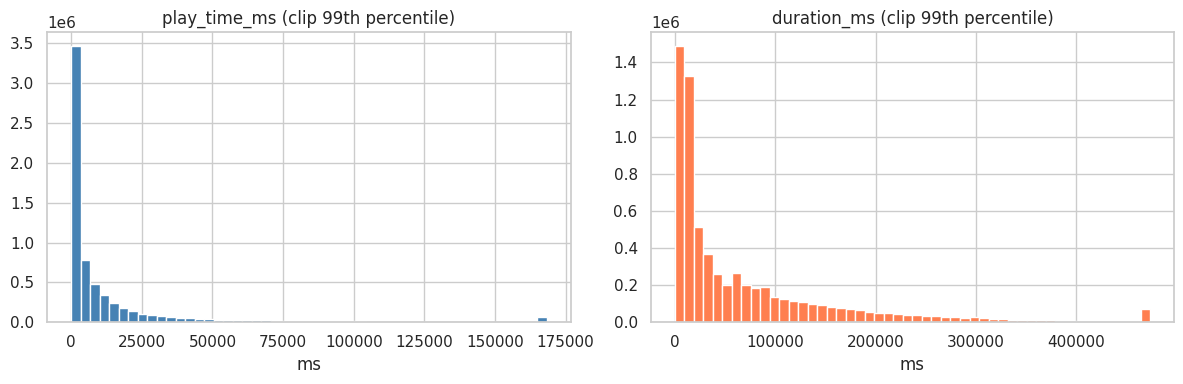

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

log_main['play_time_ms'].clip(upper=log_main['play_time_ms'].quantile(0.99)).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('play_time_ms (clip 99th percentile)')
axes[0].set_xlabel('ms')

log_main['duration_ms'].clip(upper=log_main['duration_ms'].quantile(0.99)).hist(
    bins=50, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('duration_ms (clip 99th percentile)')
axes[1].set_xlabel('ms')

plt.tight_layout()
plt.show()

### 1.4 Watch Ratio (thô)

count    6.129856e+06
mean     4.201654e-01
std      8.385900e-01
min      0.000000e+00
25%      1.138444e-02
50%      1.115355e-01
75%      6.179480e-01
max      1.307408e+02
dtype: float64

watch_ratio > 1 (play > duration): 1,009,521 rows
watch_ratio = NaN (duration = 0) : 527,205 rows


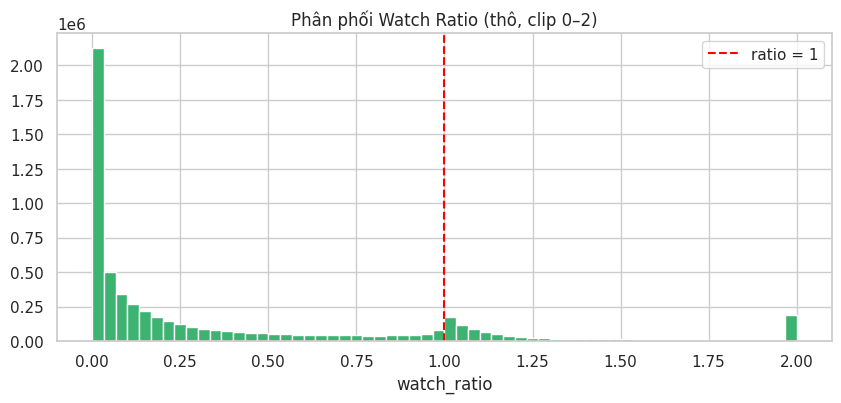

In [26]:
# Tính watch_ratio thô để quan sát, không lưu vào df
watch_ratio_raw = (
    log_main['play_time_ms'] / log_main['duration_ms'].replace(0, np.nan)
)

print(watch_ratio_raw.describe())
print(f"\nwatch_ratio > 1 (play > duration): {(watch_ratio_raw > 1).sum():,} rows")
print(f"watch_ratio = NaN (duration = 0) : {watch_ratio_raw.isnull().sum():,} rows")

watch_ratio_raw.clip(0, 2).hist(bins=60, color='mediumseagreen', edgecolor='white')
plt.title('Phân phối Watch Ratio (thô, clip 0–2)')
plt.xlabel('watch_ratio')
plt.axvline(1.0, color='red', linestyle='--', label='ratio = 1')
plt.legend()
plt.show()

### 1.5 Tương tác người dùng (clicks, likes, shares)

Tỷ lệ tương tác (%)
is_click      37.73
is_like        1.60
is_forward     0.08


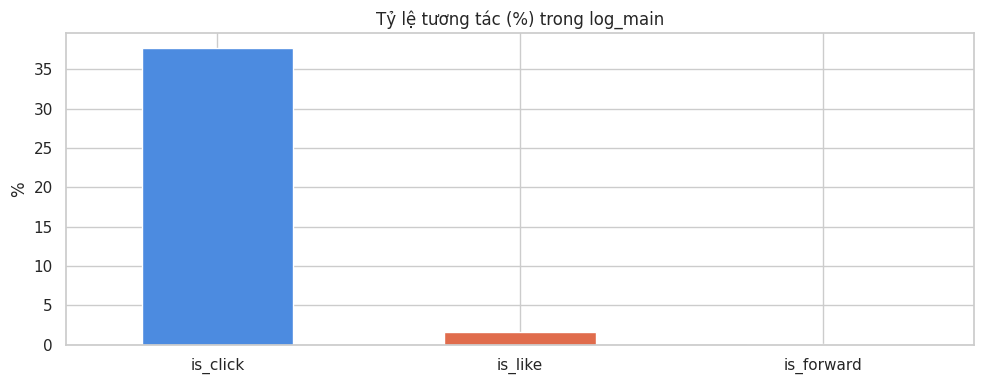

In [27]:
interaction_cols = ['is_click', 'is_like', 'is_forward']
available = [c for c in interaction_cols if c in log_main.columns]

rates = log_main[available].mean() * 100
print("Tỷ lệ tương tác (%)")
print(rates.round(2).to_string())

rates.plot(kind='bar', color=['#4C8BE0', '#E06C4C', '#4CE08B'], edgecolor='white', rot=0)
plt.title('Tỷ lệ tương tác (%) trong log_main')
plt.ylabel('%')
plt.tight_layout()
plt.show()

### 1.6 Phân phối theo thời gian

Khoảng thời gian: 2022-04-21 15:01:34.007000 → 2022-05-08 15:52:09.022000


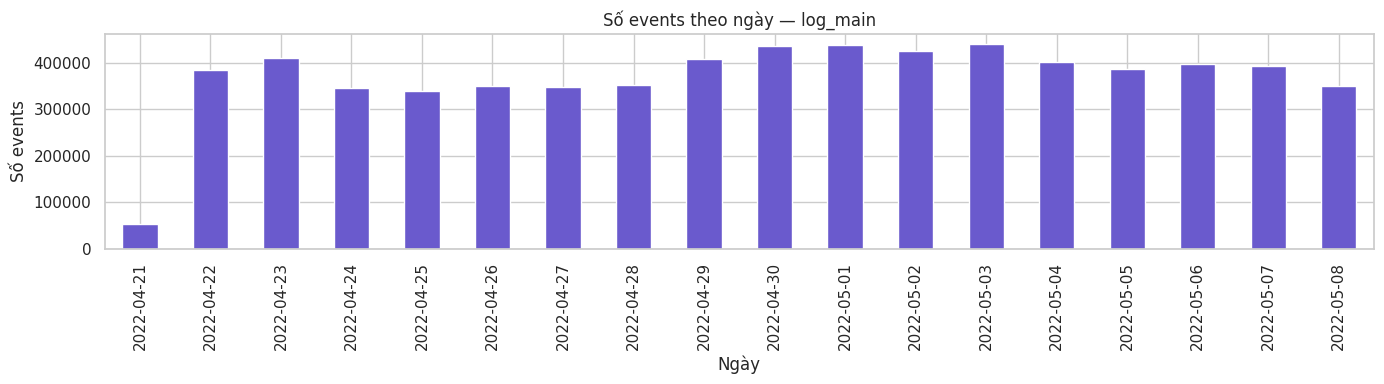

In [28]:
event_time = pd.to_datetime(log_main['time_ms'], unit='ms')
print(f"Khoảng thời gian: {event_time.min()} → {event_time.max()}")

event_time.dt.date.value_counts().sort_index().plot(
    kind='bar', figsize=(14, 4), color='slateblue', edgecolor='white'
)
plt.title('Số events theo ngày — log_main')
plt.xlabel('Ngày')
plt.ylabel('Số events')
plt.tight_layout()
plt.show()

---
## 2. EDA — `user_features`

### 2.1 Cấu trúc & Null

In [29]:
print("Shape:", user_feat.shape)
user_feat.head()

Shape: (1000, 31)


,user_id,user_active_degree,is_lowactive_period,is_live_streamer,is_video_author,follow_user_num,follow_user_num_range,fans_user_num,fans_user_num_range,friend_user_num,...,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
0,0,full_active,0,1,1,514,500+,150,"[100,1k)",34,...,135,6,3,0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,full_active,0,-124,1,457,"(250,500]",20,"[10,100)",3,...,283,6,2,2,1.0,0.0,1.0,0.0,0.0,0.0
2,2,full_active,0,-124,1,8,"(0,10]",26,"[10,100)",3,...,275,5,2,2,0.0,0.0,0.0,1.0,0.0,0.0
3,3,full_active,0,1,1,91,"(50,100]",2166,"[1k,5k)",14,...,118,6,2,2,1.0,0.0,0.0,0.0,0.0,0.0
4,4,full_active,0,-124,1,261,"(250,500]",10,"[10,100)",4,...,378,3,3,0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
null_user = user_feat.isnull().sum()
null_user = null_user[null_user > 0]
print("Null values:")
print(null_user.to_string() if len(null_user) else "Không có null")

Null values:
onehot_feat4     33
onehot_feat12    33
onehot_feat13    33
onehot_feat14    33
onehot_feat15    33
onehot_feat16    33
onehot_feat17    33


### 2.2 Phân phối `user_active_degree`

user_active_degree
full_active          640
high_active          233
middle_active         83
2_14_day_new          23
low_active            17
30day_retention        2
single_low_active      2
Name: count, dtype: int64


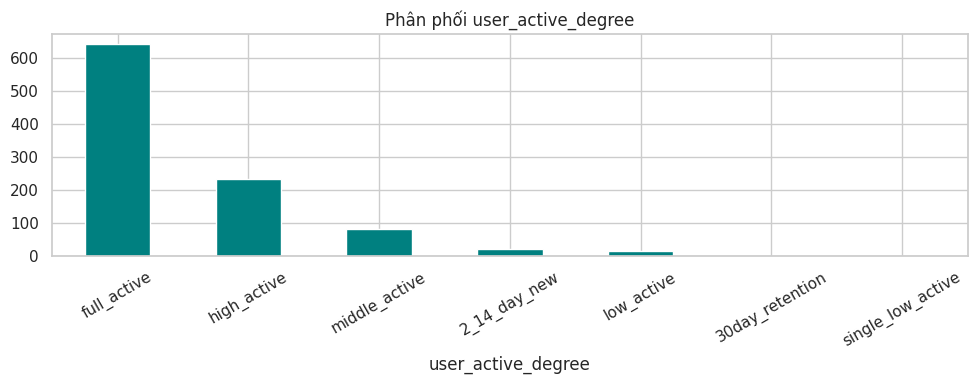

In [31]:
if 'user_active_degree' in user_feat.columns:
    vc = user_feat['user_active_degree'].value_counts()
    print(vc)
    vc.plot(kind='bar', color='teal', edgecolor='white', rot=30)
    plt.title('Phân phối user_active_degree')
    plt.tight_layout()
    plt.show()

### 2.3 Thống kê các cột số

In [32]:
user_feat.describe(include='number')

,user_id,is_lowactive_period,is_live_streamer,is_video_author,follow_user_num,fans_user_num,friend_user_num,register_days,onehot_feat0,onehot_feat1,...,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
count,1000.000000,1000.0,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,967.000000,967.000000,967.000000,967.000000,967.000000,967.000000
mean,499.500000,0.0,-96.750000,0.80800,395.35100,718.136000,111.419000,1231.451000,0.570000,2.96100,...,235.788000,3.564000,2.36400,0.521000,0.724922,0.062048,0.116856,0.028956,0.039297,0.009307
std,288.819436,0.0,51.636749,0.39407,680.41692,6297.868509,364.105447,697.950252,0.495323,1.61929,...,125.893853,1.858321,1.24461,0.871963,0.446784,0.241367,0.321415,0.167768,0.194401,0.096073
min,0.000000,0.0,-124.000000,0.00000,0.00000,0.000000,0.000000,22.000000,0.000000,0.00000,...,8.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,249.750000,0.0,-124.000000,1.00000,46.00000,9.000000,2.000000,702.500000,0.000000,2.00000,...,118.000000,2.000000,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,499.500000,0.0,-124.000000,1.00000,160.50000,43.000000,14.000000,1234.000000,1.000000,3.00000,...,248.000000,4.000000,3.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,749.250000,0.0,-124.000000,1.00000,419.25000,198.250000,77.000000,1751.250000,1.000000,4.00000,...,348.000000,5.000000,3.00000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,999.000000,0.0,1.000000,1.00000,5000.00000,156158.000000,4690.000000,3187.000000,1.000000,6.00000,...,453.000000,6.000000,4.00000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
## 3. EDA — `video_features_basic`

### 3.1 Cấu trúc & Null

In [33]:
print("Shape:", vid_basic.shape)
vid_basic.head()

Shape: (4371868, 12)


,video_id,author_id,video_type,upload_dt,upload_type,visible_status,video_duration,server_width,server_height,music_id,music_type,tag
0,0,7349781,NORMAL,2022-04-10,LongImport,0.0,87433.0,720.0,1280.0,9155697141,9.0,39
1,1,2103883,NORMAL,2022-04-10,Kmovie,0.0,218066.0,720.0,1280.0,6355810746,9.0,2
2,2,5067285,NORMAL,2022-04-09,ShortImport,0.0,9233.0,720.0,1280.0,6618412736,4.0,1
3,3,7048760,NORMAL,2022-04-11,Web,0.0,16433.0,720.0,1280.0,9161677205,9.0,7
4,4,8635271,NORMAL,2022-04-09,Web,0.0,38766.0,720.0,1280.0,9141092381,9.0,9


In [34]:
null_vid = vid_basic.isnull().sum()
null_vid = null_vid[null_vid > 0]
print("Null values:")
print(null_vid.to_string() if len(null_vid) else "Không có null")

Null values:
upload_dt             58
visible_status         5
video_duration    573057
server_width           7
server_height          7
music_type         59952
tag               137484


### 3.2 Phân phối `video_type`

video_type
NORMAL     4361638
AD            9985
UNKNOWN        245
Name: count, dtype: int64


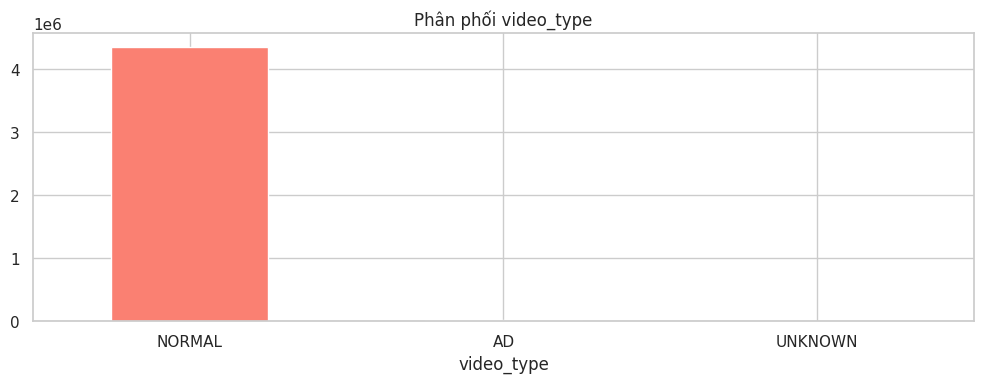

In [35]:
if 'video_type' in vid_basic.columns:
    vc = vid_basic['video_type'].value_counts()
    print(vc)
    vc.plot(kind='bar', color='salmon', edgecolor='white', rot=0)
    plt.title('Phân phối video_type')
    plt.tight_layout()
    plt.show()

### 3.3 Phân phối `video_duration` (ms)

count    3.798811e+06
mean     7.570788e+04
std      1.060211e+05
min      4.000000e+01
25%      1.206200e+04
50%      3.510000e+04
75%      9.753300e+04
max      1.651308e+07
Name: video_duration, dtype: float64


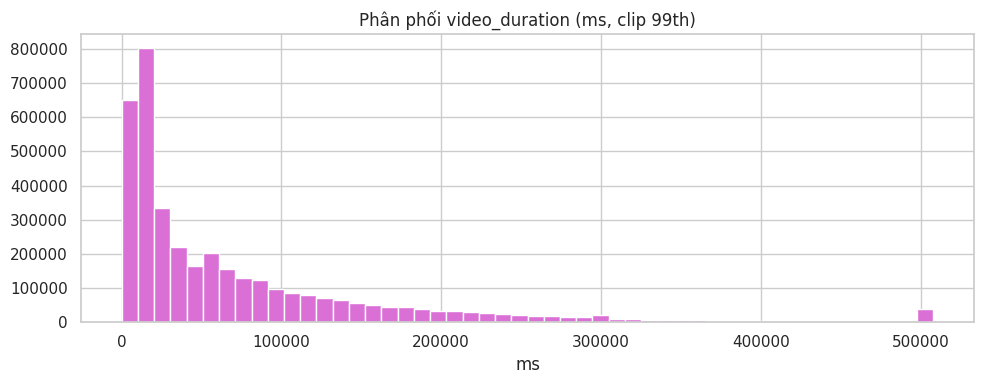

In [36]:
if 'video_duration' in vid_basic.columns:
    dur = vid_basic['video_duration'].dropna()
    print(dur.describe())
    dur.clip(upper=dur.quantile(0.99)).hist(bins=50, color='orchid', edgecolor='white')
    plt.title('Phân phối video_duration (ms, clip 99th)')
    plt.xlabel('ms')
    plt.tight_layout()
    plt.show()

In [37]:
import os

SAMPLE_DIR = "../data/sample/"
os.makedirs(SAMPLE_DIR, exist_ok=True)

# Chuẩn bị df export: chuyển time_ms → string ISO để tương thích JSON/Kafka
df_export = log_main.copy()
df_export['event_time'] = pd.to_datetime(df_export['time_ms'], unit='ms').astype(str)

total_rows = len(df_export)
print(f"Tổng rows log_main: {total_rows:,}")
print()

Tổng rows log_main: 6,657,061



In [38]:
# ── Sample files ──────────────────────────────────────────────────────────────
samples = {
    '100k'  :   100_000,
    '500k'  :   500_000,
    '1000k' : 1_000_000,
}

print('=' * 60)
print(f"{'File':<45} {'Dòng':>10}  {'Size':>8}")
print('=' * 60)

for name, n in samples.items():
    if n > total_rows:
        print(f"    Bỏ qua '{name}': yêu cầu {n:,} > có {total_rows:,} rows")
        continue
    sample = df_export.sample(n=n, random_state=42)
    path   = SAMPLE_DIR + f"kuairand_logs_{name}.csv"
    sample.to_csv(path, index=False)
    size_mb = os.path.getsize(path) / 1e6
    print(f"  {path:<43} {n:>10,}  {size_mb:>6.1f} MB")

# ── Full clean export ─────────────────────────────────────────────────────────
full_path = SAMPLE_DIR + "kuairand_logs_full_clean.csv"
df_export.to_csv(full_path, index=False)
size_full = os.path.getsize(full_path) / 1e6
print(f"  {full_path:<43} {total_rows:>10,}  {size_full:>6.1f} MB")

print('=' * 60)
print(f"\n Xong! Kiểm tra thư mục: {SAMPLE_DIR}")

File                                                Dòng      Size
  ../data/sample/kuairand_logs_100k.csv          100,000     9.8 MB
  ../data/sample/kuairand_logs_500k.csv          500,000    49.0 MB
  ../data/sample/kuairand_logs_1000k.csv       1,000,000    97.9 MB
  ../data/sample/kuairand_logs_full_clean.csv  6,657,061   652.1 MB

 Xong! Kiểm tra thư mục: ../data/sample/
